<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR6/DR6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations torch torchvision torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured")

import os
DOWNLOAD_DIR = "/content/aptos"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d mariaherrerot/aptos2019 -p {DOWNLOAD_DIR}
!ls -lh /content/aptos
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos
print("✅ Dataset extracted")

Saving kaggle.json to kaggle.json
✅ Kaggle configured
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:23<00:00, 103MB/s] 

total 8.1G
-rw-r--r-- 1 root root 8.1G Nov 17  2021 aptos2019.zip
✅ Dataset extracted


In [ ]:
import os
for root, dirs, files_list in os.walk("/content/aptos"):
    print(root)
    print("Folders:", dirs[:3])
    print("Files:", files_list[:3])
    print("-"*40)

/content/aptos
Folders: ['train_images', 'test_images', 'val_images']
Files: ['aptos2019.zip', 'valid.csv', 'train_1.csv']
----------------------------------------
/content/aptos/train_images
Folders: ['train_images']
Files: []
----------------------------------------
/content/aptos/train_images/train_images
Folders: []
Files: ['4b6cb0bcfd44.png', 'b376def52ccc.png', 'd6b109c82067.png']
----------------------------------------
/content/aptos/test_images
Folders: ['test_images']
Files: []
----------------------------------------
/content/aptos/test_images/test_images
Folders: []
Files: ['f6d760566a51.png', 'f361060eda3e.png', 'f7116e7b2f4e.png']
----------------------------------------
/content/aptos/val_images
Folders: ['val_images']
Files: []
----------------------------------------
/content/aptos/val_images/val_images
Folders: []
Files: ['0fe31196e0e8.png', '18b99159a14f.png', '1120f6d08d95.png']
----------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from tqdm import tqdm
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage import measure
from skimage.feature import graycomatrix, graycoprops
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries imported | Device: {device}")

✅ Libraries imported | Device: cuda


In [ ]:
from pathlib import Path

DATA_DIR = Path("/content/aptos")
TRAIN_CSV = DATA_DIR / "train_1.csv"
IMG_DIR   = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

print("CSV Path:", TRAIN_CSV)
print("Image Folder:", IMG_DIR)

CSV Path: /content/aptos/train_1.csv
Image Folder: /content/aptos/train_images/train_images


In [ ]:
df = pd.read_csv(TRAIN_CSV)
print("Columns:", df.columns.tolist())

df["img_path"]   = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["exists"]     = df["img_path"].apply(os.path.isfile)
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)

df = df[df["exists"]].reset_index(drop=True)
print(f"✅ Total images found: {len(df)}")
df.head()

Columns: ['id_code', 'diagnosis']
✅ Total images found: 2930


,id_code,diagnosis,img_path,exists,grade_name
0,1ae8c165fd53,2,/content/aptos/train_images/train_images/1ae8c...,True,Moderate
1,1b329a127307,1,/content/aptos/train_images/train_images/1b329...,True,Mild
2,1b32e1d775ea,4,/content/aptos/train_images/train_images/1b32e...,True,Proliferative DR
3,1b3647865779,0,/content/aptos/train_images/train_images/1b364...,True,No DR
4,1b398c0494d1,0,/content/aptos/train_images/train_images/1b398...,True,No DR


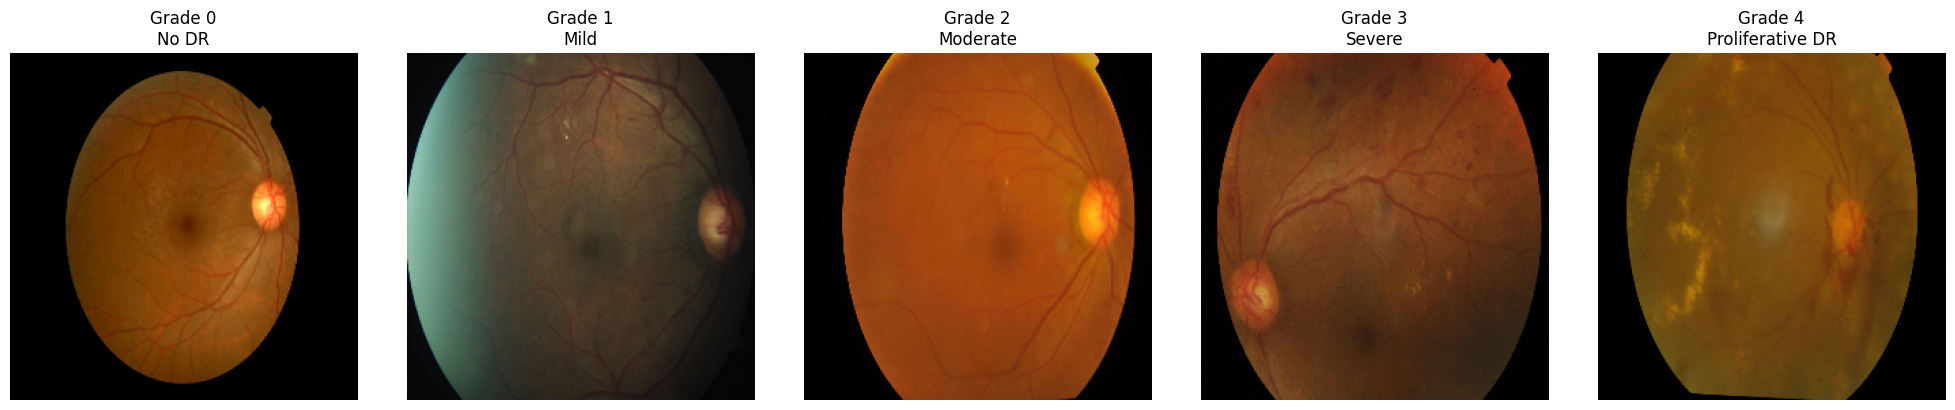

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    row = df[df["diagnosis"] == grade].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    axes[grade].imshow(img)
    axes[grade].set_title(f"Grade {grade}\n{GRADE_LABELS[grade]}")
    axes[grade].axis("off")
plt.tight_layout()
plt.show()

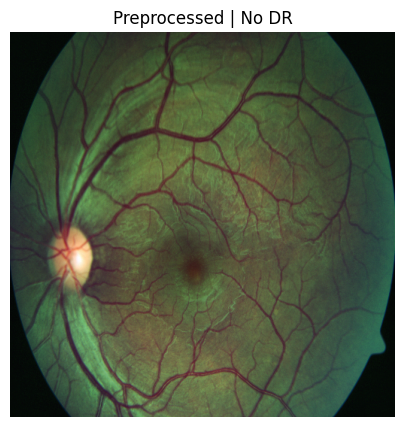

Shape: (512, 512, 3)


In [ ]:
# Retinal images benefit greatly from green-channel preprocessing
# and removing the black border (field-of-view mask)

def preprocess_retinal_image(img_path, size=512):
    """
    Load, crop black border, enhance contrast, resize.
    Returns: RGB uint8 image of shape (size, size, 3)
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- crop black border ---
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    # --- CLAHE on green channel for lesion contrast ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_g = clahe.apply(img[:, :, 1])          # green channel
    img[:, :, 1] = img_g

    img = cv2.resize(img, (size, size))
    return img


# Quick test
sample = df.iloc[100]
proc = preprocess_retinal_image(sample["img_path"])
plt.figure(figsize=(5, 5))
plt.imshow(proc)
plt.title(f"Preprocessed | {sample['grade_name']}")
plt.axis("off")
plt.show()
print("Shape:", proc.shape)

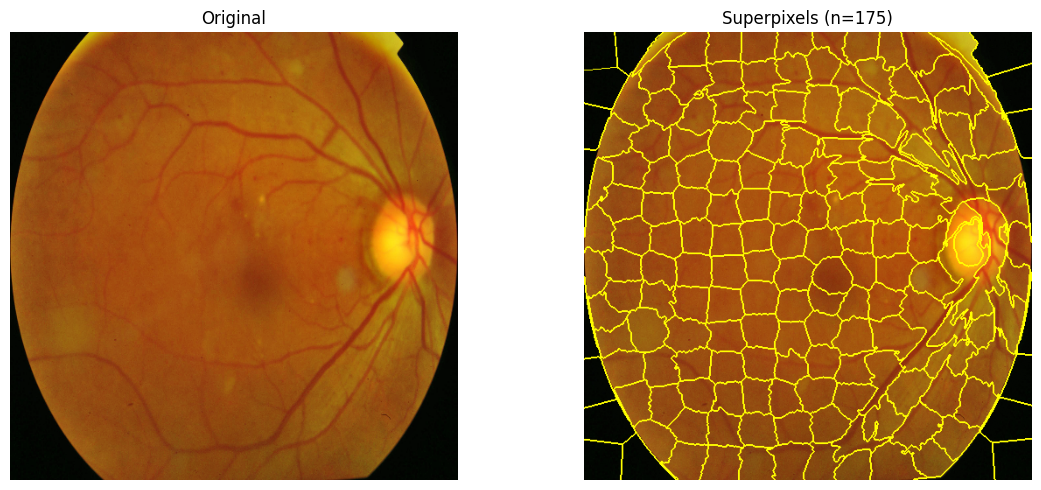

In [ ]:
def generate_superpixels(img_rgb, n_segments=200, compactness=10):
    """
    img_rgb : uint8 (H,W,3)
    Returns:
        segments : (H,W) int array — superpixel label map
        n_sp     : actual number of superpixels
    """
    img_float = img_as_float(img_rgb)
    segments  = slic(img_float,
                     n_segments=n_segments,
                     compactness=compactness,
                     sigma=1,
                     start_label=0)
    return segments, segments.max() + 1


# Visualise
img_test  = preprocess_retinal_image(df.iloc[0]["img_path"])
segs, n   = generate_superpixels(img_test, n_segments=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_test);           axes[0].set_title("Original");        axes[0].axis("off")
axes[1].imshow(mark_boundaries(img_as_float(img_test), segs, color=(1,1,0)))
axes[1].set_title(f"Superpixels (n={n})");  axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
class SuperpixelCNN(nn.Module):
    """
    ResNet-50 backbone (paper's choice) with the classification head
    replaced by a feature embedding layer.
    """
    def __init__(self, embed_dim=256):
        super().__init__()
        backbone        = models.resnet50(pretrained=True)
        # remove final FC
        self.features   = nn.Sequential(*list(backbone.children())[:-1])
        self.embedder   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedder(x)
        return F.normalize(x, dim=1)   # L2-normalise


cnn_model = SuperpixelCNN(embed_dim=256).to(device)
cnn_model.eval()
print("✅ CNN backbone ready")
print("Parameters:", sum(p.numel() for p in cnn_model.parameters()) // 1_000_000, "M")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


✅ CNN backbone ready
Parameters: 24 M


In [ ]:
SP_SIZE   = 64     # resize each superpixel crop to this
EMBED_DIM = 256

sp_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((SP_SIZE, SP_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


def extract_superpixel_patches(img_rgb, segments):
    """
    For each superpixel, crop its tight bounding-box from the image.
    Returns list of uint8 RGB crops, one per superpixel.
    """
    n_sp    = segments.max() + 1
    patches = []
    for sp_id in range(n_sp):
        mask    = (segments == sp_id)
        ys, xs  = np.where(mask)
        if len(ys) == 0:
            patches.append(np.zeros((SP_SIZE, SP_SIZE, 3), dtype=np.uint8))
            continue
        y0, y1  = ys.min(), ys.max() + 1
        x0, x1  = xs.min(), xs.max() + 1
        crop    = img_rgb[y0:y1, x0:x1].copy()
        # mask pixels outside superpixel with mean colour
        sp_mask            = mask[y0:y1, x0:x1]
        mean_col           = crop[sp_mask].mean(axis=0).astype(np.uint8)
        crop[~sp_mask]     = mean_col
        patches.append(crop)
    return patches


@torch.no_grad()
def patches_to_features(patches, model, batch_size=64):
    """
    Run patches through CNN in mini-batches → (N, EMBED_DIM) tensor
    """
    tensors = [sp_transform(p) for p in patches]
    feats   = []
    for i in range(0, len(tensors), batch_size):
        batch = torch.stack(tensors[i:i+batch_size]).to(device)
        feats.append(model(batch).cpu())
    return torch.cat(feats, dim=0)   # (N, EMBED_DIM)


# --- quick test on one image ---
img_test  = preprocess_retinal_image(df.iloc[0]["img_path"])
segs, n   = generate_superpixels(img_test, n_segments=200)
patches   = extract_superpixel_patches(img_test, segs)
feats     = patches_to_features(patches, cnn_model)
print(f"✅ Superpixel features: {feats.shape}")   # (200, 256)

✅ Superpixel features: torch.Size([175, 256])


In [ ]:
# Implementing the graph convolution from Equation (3) of the paper:
# X^(l) = σ( D^{-1/2} A D^{-1/2} X^(l-1) W^(l) )

class GraphConvLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, X, A_norm):
        """
        X      : (N, in_dim)
        A_norm : (N, N)  — symmetrically normalised adjacency (D^{-1/2} A D^{-1/2})
        """
        return F.relu(self.W(A_norm @ X))


class GCN(nn.Module):
    """Two-layer GCN matching the paper's architecture."""
    def __init__(self, in_dim=256, hidden_dim=128, out_dim=64):
        super().__init__()
        self.layer1 = GraphConvLayer(in_dim,     hidden_dim)
        self.layer2 = GraphConvLayer(hidden_dim, out_dim)

    def forward(self, X, A_norm):
        X = self.layer1(X, A_norm)
        X = self.layer2(X, A_norm)
        return F.normalize(X, dim=1)


def build_knn_adjacency(features, k=10):
    """
    Build symmetric KNN adjacency matrix + symmetrically normalised version.
    features : (N, D) numpy or tensor
    Returns  : A_norm (N, N) torch.FloatTensor  on same device as features
    """
    if isinstance(features, torch.Tensor):
        F_np = features.detach().cpu().numpy()
    else:
        F_np = features

    N   = F_np.shape[0]
    k   = min(k, N - 1)
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(F_np)
    _, indices = nbrs.kneighbors(F_np)

    A = np.zeros((N, N), dtype=np.float32)
    for i, row in enumerate(indices):
        for j in row[1:]:          # skip self
            A[i, j] = 1.0
            A[j, i] = 1.0          # symmetry

    # D^{-1/2} A D^{-1/2}
    D_inv_sqrt = np.diag(1.0 / (np.sqrt(A.sum(axis=1) + 1e-8)))
    A_norm     = D_inv_sqrt @ A @ D_inv_sqrt

    if isinstance(features, torch.Tensor):
        return torch.tensor(A_norm, dtype=torch.float32).to(features.device)
    return torch.tensor(A_norm, dtype=torch.float32)


print("✅ GCN and KNN adjacency builder ready")

✅ GCN and KNN adjacency builder ready


In [ ]:
# ── Loss 1: Graph-Centre Loss  (Equation 4) ──────────────────────────────────
def graph_centre_loss(Z, A):
    """
    L_gc = 0.5 * Σ_k Σ_j  A_kj * ||Z_j - Z_k||²
    Z : (N, D)   A : (N, N)
    """
    diff  = Z.unsqueeze(1) - Z.unsqueeze(0)          # (N,N,D)
    dist2 = (diff ** 2).sum(dim=-1)                   # (N,N)
    return 0.5 * (A * dist2).sum()


# ── Loss 2: Pseudo-Contrastive Loss  (Equations 5 & 6) ──────────────────────
def pseudo_labels(features_np, k=10, lam=2):
    """
    For each pair (i,j): label=1 if |K_i ∩ K_j| > λ, else 0.
    Returns (N,N) int numpy array.
    """
    N    = features_np.shape[0]
    k    = min(k, N - 1)
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(features_np)
    _, idx = nbrs.kneighbors(features_np)
    knn_sets = [set(idx[i, 1:]) for i in range(N)]

    L = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(i+1, N):
            shared = len(knn_sets[i] & knn_sets[j])
            if shared > lam:
                L[i, j] = L[j, i] = 1.0
    return L


def pseudo_contrastive_loss(Z, pseudo_L, margin=1.0):
    """
    L_pc  (Equation 6)
    Z        : (N, D)
    pseudo_L : (N, N) float tensor  (0 or 1)
    """
    diff   = Z.unsqueeze(1) - Z.unsqueeze(0)          # (N,N,D)
    d      = diff.norm(dim=-1)                         # (N,N)
    same   = pseudo_L * d ** 2
    diff_  = (1 - pseudo_L) * F.relu(margin - d) ** 2
    N2     = Z.shape[0] ** 2
    return 0.5 * (same + diff_).sum() / N2


# ── Loss 3: Transform-Invariant Loss  (Equation 7) ──────────────────────────
def transform_invariant_loss(Z, Z_aug):
    """
    L_ti = (1/B) Σ_k ||Z_k - Z'_k||
    """
    return (Z - Z_aug).norm(dim=1).mean()


print("✅ All three loss functions defined")

✅ All three loss functions defined


In [ ]:
import albumentations as A

aug_pipeline = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
    A.ElasticTransform(p=0.2),
])

def augment_patches(patches):
    """Apply same augmentation pipeline to each patch."""
    aug_patches = []
    for p in patches:
        try:
            aug = aug_pipeline(image=p)["image"]
        except Exception:
            aug = p
        aug_patches.append(aug)
    return aug_patches

print("✅ Augmentation pipeline ready")

✅ Augmentation pipeline ready


In [ ]:
class DGCN(nn.Module):
    """
    Deep Graph Correlation Network — full pipeline per paper.
    CNN  →  KNN graph  →  GCN  →  three losses
    """
    def __init__(self, embed_dim=256, gcn_hidden=128, gcn_out=64, k=10):
        super().__init__()
        self.cnn  = SuperpixelCNN(embed_dim=embed_dim)
        self.gcn  = GCN(in_dim=embed_dim, hidden_dim=gcn_hidden, out_dim=gcn_out)
        self.k    = k

    def forward(self, patches_tensor, patches_aug_tensor):
        """
        patches_tensor     : (N, 3, 64, 64)  original
        patches_aug_tensor : (N, 3, 64, 64)  augmented
        Returns: Z, Z_aug, A_norm, cnn_feats
        """
        F_orig = self.cnn(patches_tensor)                   # (N, embed)
        F_aug  = self.cnn(patches_aug_tensor)               # (N, embed)

        A_norm = build_knn_adjacency(F_orig, k=self.k).to(F_orig.device)

        Z      = self.gcn(F_orig, A_norm)                   # (N, gcn_out)
        Z_aug  = self.gcn(F_aug,  A_norm)

        return Z, Z_aug, A_norm, F_orig


dgcn_model = DGCN(embed_dim=256, gcn_hidden=128, gcn_out=64, k=10).to(device)
print("✅ DGCN model instantiated")
print("Total params:", sum(p.numel() for p in dgcn_model.parameters()) // 1_000_000, "M")

✅ DGCN model instantiated
Total params: 24 M


In [ ]:
def train_dgcn_on_image(img_rgb, dgcn, optimizer,
                         n_segments=150, k=10, lam=2,
                         alpha=0.5, beta=0.3, margin=1.0,
                         epochs=30):
    """
    Train DGCN on superpixels of ONE retinal image (unsupervised).
    Returns: trained graph features Z (N, gcn_out) as numpy
    """
    segments, n_sp = generate_superpixels(img_rgb, n_segments=n_segments)
    patches        = extract_superpixel_patches(img_rgb, segments)
    patches_aug    = augment_patches(patches)

    # to tensors
    def to_tensor_batch(patch_list):
        return torch.stack([sp_transform(p) for p in patch_list]).to(device)

    T_orig = to_tensor_batch(patches)
    T_aug  = to_tensor_batch(patches_aug)

    dgcn.train()
    history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        Z, Z_aug, A_norm, F_orig = dgcn(T_orig, T_aug)

        # pseudo labels (computed from CNN features, not GCN)
        PL_np = pseudo_labels(F_orig.detach().cpu().numpy(), k=k, lam=lam)
        PL    = torch.tensor(PL_np, dtype=torch.float32).to(device)

        L_gc  = graph_centre_loss(Z, A_norm)
        L_pc  = pseudo_contrastive_loss(Z, PL, margin=margin)
        L_ti  = transform_invariant_loss(Z, Z_aug)

        loss  = L_pc + alpha * L_gc + beta * L_ti
        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss={loss.item():.4f} "
                  f"(pc={L_pc.item():.3f} gc={L_gc.item():.3f} ti={L_ti.item():.3f})")

    dgcn.eval()
    with torch.no_grad():
        Z_final, _, _, _ = dgcn(T_orig, T_orig)

    return Z_final.cpu().numpy(), segments, history


print("✅ Training function ready")

✅ Training function ready


In [ ]:
def get_retinal_mask(img_rgb, threshold=15):
    gray   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask.astype(bool)


def get_vessel_mask(img_rgb):
    green    = img_rgb[:, :, 1]
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_eq = clahe.apply(green)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    tophat   = cv2.morphologyEx(green_eq, cv2.MORPH_BLACKHAT, kernel)
    _, vessel_bin = cv2.threshold(tophat, 40, 255, cv2.THRESH_BINARY)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        vessel_bin, connectivity=8)
    filtered = np.zeros_like(vessel_bin)
    for i in range(1, num_labels):
        area   = stats[i, cv2.CC_STAT_AREA]
        w      = stats[i, cv2.CC_STAT_WIDTH]
        h      = stats[i, cv2.CC_STAT_HEIGHT]
        aspect = max(w, h) / (min(w, h) + 1e-6)
        if area > 200 and aspect > 2.5:
            filtered[labels == i] = 255
    k2       = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    filtered = cv2.dilate(filtered, k2, iterations=1)
    return filtered.astype(bool)


def get_optic_disc_mask(img_rgb, margin=65):
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    H, W    = gray.shape
    blurred = cv2.GaussianBlur(gray, (51, 51), 0)
    _, _, _, max_loc = cv2.minMaxLoc(blurred)
    cx, cy  = max_loc
    Y, X    = np.ogrid[:H, :W]
    return (np.sqrt((X - cx)**2 + (Y - cy)**2) < margin)


def get_macula_mask(img_rgb, margin=55):
    """
    Exclude the macula — the dark oval in the centre of the retina.
    It is naturally darker than surroundings and causes false positives.
    Strategy: find the darkest region in the central 40% of the image,
    away from the optic disc.
    """
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    H, W  = gray.shape

    # Restrict search to central region
    cx_img, cy_img = W // 2, H // 2
    margin_search  = int(min(H, W) * 0.35)

    # Blur heavily to find dark blob center
    blurred = cv2.GaussianBlur(gray, (71, 71), 0)

    # Mask out the disc area before finding macula
    disc_mask = get_optic_disc_mask(img_rgb, margin=70)
    search    = blurred.copy().astype(float)
    search[disc_mask] = 255   # set disc to bright so it won't be picked

    # Find darkest point in central region
    center_roi = search[cy_img - margin_search : cy_img + margin_search,
                         cx_img - margin_search : cx_img + margin_search]
    min_val = center_roi.min()
    min_pos = np.unravel_index(center_roi.argmin(), center_roi.shape)
    my = min_pos[0] + cy_img - margin_search
    mx = min_pos[1] + cx_img - margin_search

    Y, X = np.ogrid[:H, :W]
    return (np.sqrt((X - mx)**2 + (Y - my)**2) < margin)


def compute_superpixel_scores(img_rgb, segments, n_sp,
                               vessel_mask, disc_mask, macula_mask):
    """
    Score each superpixel. Three lesion types:
      1. Dark red   — haemorrhages / microaneurysms
      2. Bright     — hard exudates (yellow-white)
      3. Cotton wool — pale grey patches
    Macula, vessel, disc each get soft penalties.
    """
    H, W       = segments.shape
    r_ch       = img_rgb[:, :, 0].astype(float)
    g_ch       = img_rgb[:, :, 1].astype(float)
    b_ch       = img_rgb[:, :, 2].astype(float)
    gray       = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(float)
    ret_mask   = get_retinal_mask(img_rgb)

    # Robust global stats using median/IQR on retinal pixels only
    ret_gray    = gray[ret_mask]
    mean_bright = np.median(ret_gray)
    std_bright  = max(
        np.percentile(ret_gray, 75) - np.percentile(ret_gray, 25), 10.0
    )
    mean_r = np.median(r_ch[ret_mask])
    mean_g = np.median(g_ch[ret_mask])
    mean_b = np.median(b_ch[ret_mask])

    scores = np.zeros(n_sp, dtype=float)

    for sp_id in range(n_sp):
        sp_mask = (segments == sp_id)
        if sp_mask.sum() == 0:
            continue

        r_m  = r_ch[sp_mask].mean()
        g_m  = g_ch[sp_mask].mean() + 1e-6
        b_m  = b_ch[sp_mask].mean() + 1e-6
        br_m = gray[sp_mask].mean()
        br_s = gray[sp_mask].std()

        # ── 1. Dark haemorrhage score ─────────────────────────────────────
        dark_z     = (mean_bright - br_m) / std_bright
        red_excess = (r_m - g_m) - (mean_r - mean_g)
        dark_score = max(0, dark_z - 0.8) * 0.6 + max(0, red_excess / 15) * 0.4
        # Crucial: only fire if superpixel IS genuinely dark
        # (rules out macula glow, slightly-dim-but-normal areas)
        if br_m > mean_bright * 0.80:
            dark_score = 0.0

        # ── 2. Hard exudate score ─────────────────────────────────────────
        bright_z     = (br_m - mean_bright) / std_bright
        yellow_ratio = (r_m + g_m) / (2.0 * b_m)
        # Exudates: clearly brighter (z>1.5) AND noticeably yellow
        bright_score = max(0, bright_z - 1.5) * 0.5 + \
                       max(0, yellow_ratio - 1.4) * 0.5
        # Hard suppress near disc (disc glow looks like exudate)
        disc_ov      = disc_mask[sp_mask].mean()
        bright_score *= max(0.0, 1.0 - disc_ov * 4)

        # ── 3. Cotton wool spot score ─────────────────────────────────────
        saturation = (max(r_m, g_m, b_m) - min(r_m, g_m, b_m)) / \
                     (max(r_m, g_m, b_m) + 1e-6)
        cws_score  = max(0, bright_z - 0.8) * max(0, 0.30 - saturation) * 2.5

        colour_score = max(dark_score, bright_score, cws_score)

        # ── Texture ───────────────────────────────────────────────────────
        texture_score = min(br_s / (std_bright + 1e-6), 2.0)

        raw = colour_score * 0.75 + texture_score * 0.25

        # ── Soft penalties ────────────────────────────────────────────────
        v_pen = 1.0 - vessel_mask[sp_mask].mean() * 0.80
        d_pen = 1.0 - disc_mask[sp_mask].mean()   * 0.95
        m_pen = 1.0 - macula_mask[sp_mask].mean() * 0.85  # NEW: macula penalty

        scores[sp_id] = raw * v_pen * d_pen * m_pen

    return scores


def detect_lesions(Z, segments, img_rgb,
                   n_clusters=3,
                   top_fraction=0.25,
                   score_weight=0.65,
                   max_coverage=0.15):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    H, W  = segments.shape
    n_sp  = segments.max() + 1

    retinal_mask = get_retinal_mask(img_rgb)
    vessel_mask  = get_vessel_mask(img_rgb)
    disc_mask    = get_optic_disc_mask(img_rgb, margin=65)
    macula_mask  = get_macula_mask(img_rgb, margin=55)

    # Hard-exclude background only
    is_bg = np.zeros(n_sp, dtype=bool)
    for sp_id in range(n_sp):
        sp_pix = retinal_mask[segments == sp_id]
        if len(sp_pix) == 0 or sp_pix.mean() < 0.4:
            is_bg[sp_id] = True

    retinal_ids = np.where(~is_bg)[0]
    print(f"  Retinal SPs: {len(retinal_ids)} / {n_sp}")

    if len(retinal_ids) < n_clusters + 1:
        print("  ⚠️ Too few superpixels")
        return np.zeros((H, W), dtype=bool), np.zeros(n_sp), 0

    # ── GCN clustering ────────────────────────────────────────────────────────
    Z_ret  = Z[retinal_ids]
    scaler = StandardScaler()
    Z_sc   = scaler.fit_transform(Z_ret)
    km     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    c_lbls = km.fit_predict(Z_sc)

    sp_labels = np.full(n_sp, -1, dtype=int)
    for i, sp_id in enumerate(retinal_ids):
        sp_labels[sp_id] = c_lbls[i]

    # ── Colour scores ─────────────────────────────────────────────────────────
    sp_scores = compute_superpixel_scores(
        img_rgb, segments, n_sp, vessel_mask, disc_mask, macula_mask
    )

    # ── GCN cluster bonus ─────────────────────────────────────────────────────
    cluster_mean = []
    for c in range(n_clusters):
        ids = retinal_ids[c_lbls == c]
        cluster_mean.append(sp_scores[ids].mean() if len(ids) else 0)

    cluster_rank   = np.argsort(cluster_mean)[::-1]
    lesion_cluster = int(cluster_rank[0])

    gcn_bonus = np.zeros(n_sp, dtype=float)
    for rank, c in enumerate(cluster_rank):
        ids = retinal_ids[c_lbls == c]
        gcn_bonus[ids] = max(0.0, 1.0 - rank * 0.5)

    print(f"  Cluster scores: {[f'{s:.4f}' for s in cluster_mean]}"
          f"  → Lesion cluster: {lesion_cluster}")

    # ── Blend scores ──────────────────────────────────────────────────────────
    cs      = sp_scores.copy()
    ret_cs  = cs[retinal_ids]
    if ret_cs.max() > ret_cs.min():
        cs[retinal_ids] = (ret_cs - ret_cs.min()) / (ret_cs.max() - ret_cs.min())

    final_scores = score_weight * cs + (1 - score_weight) * gcn_bonus

    # ── Threshold ─────────────────────────────────────────────────────────────
    ret_final  = final_scores[retinal_ids]
    thresh     = np.percentile(ret_final, (1 - top_fraction) * 100)
    lesion_ids = retinal_ids[ret_final >= thresh]

    lesion_mask = np.zeros((H, W), dtype=bool)
    for sp_id in lesion_ids:
        lesion_mask[segments == sp_id] = True

    # ── Enforce max_coverage ──────────────────────────────────────────────────
    if lesion_mask.mean() > max_coverage:
        for pct in range(int((1 - top_fraction) * 100), 99):
            t2   = np.percentile(ret_final, pct)
            ids2 = retinal_ids[ret_final >= t2]
            lm2  = np.zeros((H, W), dtype=bool)
            for sp_id in ids2:
                lm2[segments == sp_id] = True
            if lm2.mean() <= max_coverage:
                lesion_mask = lm2
                lesion_ids  = ids2
                break

    print(f"  Lesion SPs: {len(lesion_ids)} | "
          f"Coverage: {100*lesion_mask.mean():.1f}%")

    return lesion_mask, sp_labels, lesion_cluster


print("✅ Detection with macula exclusion ready")

✅ Detection with macula exclusion ready


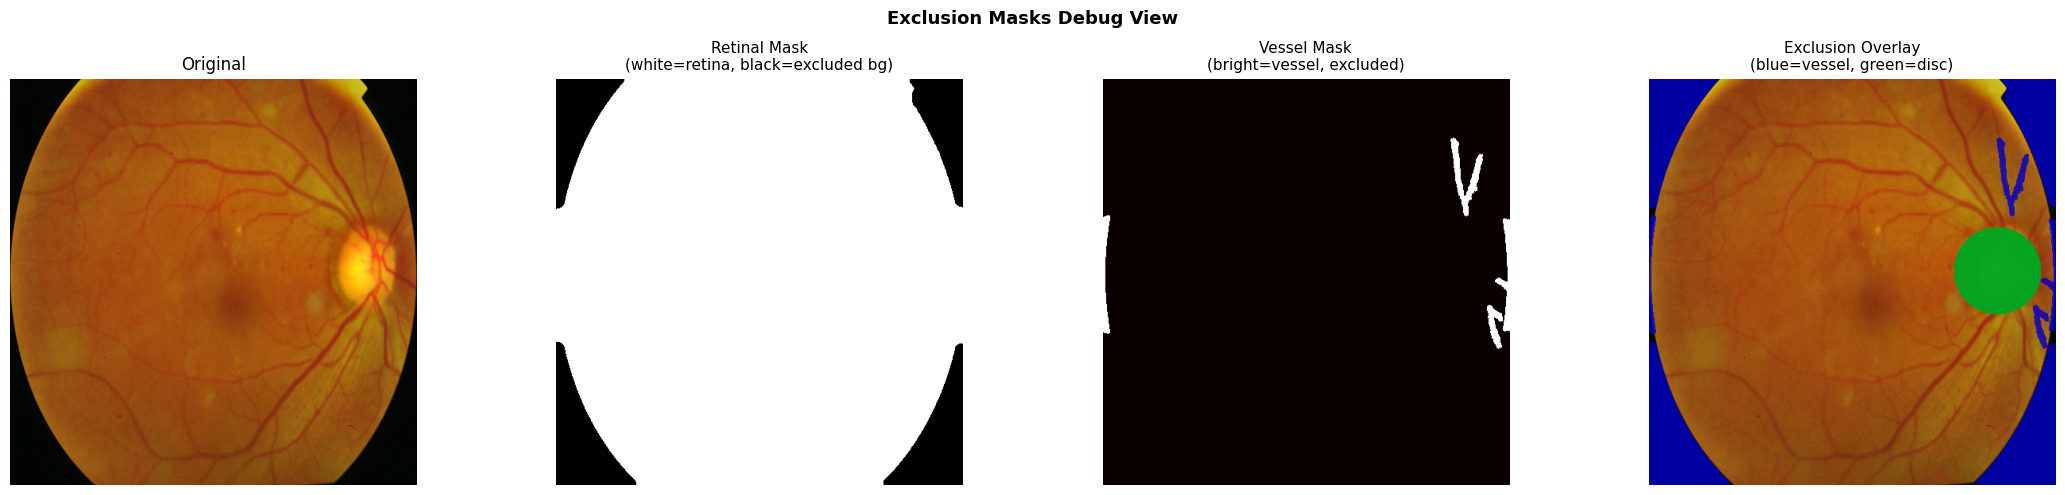

✅ If vessels show in blue and disc in green, masks are working correctly


In [ ]:
def visualize_exclusion_masks(img_rgb):
    """
    Debug view: shows what background/vessel/disc masks look like.
    Run this to verify exclusions are correct before lesion detection.
    """
    retinal = get_retinal_mask(img_rgb)
    vessel  = get_vessel_mask(img_rgb)
    disc    = get_optic_disc_mask(img_rgb, margin=55)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original", fontsize=12); axes[0].axis("off")

    axes[1].imshow(retinal, cmap='gray')
    axes[1].set_title("Retinal Mask\n(white=retina, black=excluded bg)",
                      fontsize=11); axes[1].axis("off")

    axes[2].imshow(vessel, cmap='hot')
    axes[2].set_title("Vessel Mask\n(bright=vessel, excluded)",
                      fontsize=11); axes[2].axis("off")

    # combined exclusion overlay
    exclude_vis = img_rgb.copy().astype(np.float32)
    exclude_all = (~retinal) | vessel | disc
    exclude_vis[exclude_all] = (
        exclude_vis[exclude_all] * 0.2 +
        np.array([0, 0, 200], dtype=np.float32) * 0.8
    )
    # disc in green
    exclude_vis[disc & retinal] = (
        exclude_vis[disc & retinal] * 0.2 +
        np.array([0, 200, 0], dtype=np.float32) * 0.8
    )
    axes[3].imshow(exclude_vis.astype(np.uint8))
    axes[3].set_title("Exclusion Overlay\n(blue=vessel, green=disc)",
                      fontsize=11); axes[3].axis("off")

    plt.suptitle("Exclusion Masks Debug View", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Test on one image
test_img = preprocess_retinal_image(df[df["diagnosis"] >= 2].iloc[0]["img_path"])
visualize_exclusion_masks(test_img)
print("✅ If vessels show in blue and disc in green, masks are working correctly")

In [ ]:
def visualize_result(img_rgb, segments, lesion_mask, sp_labels,
                     lesion_cluster, history, title=""):
    """
    Shows: Original | Superpixels | Lesion Overlay | Training Loss
    Original and detected lesion side-by-side for easy comparison.
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # ── 1. Original image ────────────────────────────────────────────────────
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis("off")

    # ── 2. Superpixel boundaries ──────────────────────────────────────────────
    axes[1].imshow(mark_boundaries(img_as_float(img_rgb), segments,
                                   color=(1, 1, 0), mode='thick'))
    n_sp = segments.max() + 1
    axes[1].set_title(f"SLIC Superpixels (n={n_sp})", fontsize=12)
    axes[1].axis("off")

    # ── 3. Lesion overlay (side-by-side with original context) ───────────────
    overlay = img_rgb.copy().astype(np.float32)

    # semi-transparent red for lesion regions
    red_tint         = np.array([220, 30, 30], dtype=np.float32)
    overlay[lesion_mask] = (overlay[lesion_mask] * 0.35 +
                             red_tint * 0.65)

    # draw lesion contour border in bright yellow
    lesion_uint8  = lesion_mask.astype(np.uint8) * 255
    contours, _   = cv2.findContours(lesion_uint8,
                                      cv2.RETR_EXTERNAL,
                                      cv2.CHAIN_APPROX_SIMPLE)
    overlay_bgr   = cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.drawContours(overlay_bgr, contours, -1, (0, 255, 255), 2)
    overlay_final = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    axes[2].imshow(overlay_final)
    lesion_pct = 100 * lesion_mask.mean()
    axes[2].set_title(f"Detected Lesions\n({lesion_pct:.1f}% of image)",
                      fontsize=12)
    axes[2].axis("off")

    # ── 4. Training loss curve ────────────────────────────────────────────────
    axes[3].plot(history, color='steelblue', linewidth=2)
    axes[3].fill_between(range(len(history)), history,
                         alpha=0.15, color='steelblue')
    axes[3].set_title("DGCN Training Loss", fontsize=12)
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Loss")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def visualize_side_by_side(img_rgb, lesion_mask, title=""):
    """
    Clean 2-panel: Original vs Lesion Detection — easy comparison.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Retinal Image", fontsize=13)
    axes[0].axis("off")

    overlay = img_rgb.copy().astype(np.float32)
    overlay[lesion_mask] = (overlay[lesion_mask] * 0.35 +
                             np.array([220, 30, 30], dtype=np.float32) * 0.65)

    # yellow contour outline
    lesion_uint8 = lesion_mask.astype(np.uint8) * 255
    contours, _  = cv2.findContours(lesion_uint8,
                                     cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    overlay_bgr  = cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.drawContours(overlay_bgr, contours, -1, (0, 255, 255), 2)
    overlay_rgb  = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    axes[1].imshow(overlay_rgb)
    lesion_pct = 100 * lesion_mask.mean()
    axes[1].set_title(f"DGCN Lesion Detection\n"
                      f"(red={lesion_pct:.1f}% flagged | "
                      f"yellow=contour boundary)", fontsize=13)
    axes[1].axis("off")

    # add a simple legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red',    alpha=0.7, label='Detected Lesion'),
        Patch(facecolor='yellow', alpha=0.9, label='Lesion Boundary'),
    ]
    axes[1].legend(handles=legend_elements, loc='lower left',
                   fontsize=11, framealpha=0.8)

    plt.tight_layout()
    plt.show()


print("✅ Side-by-side visualisation functions ready")

✅ Side-by-side visualisation functions ready


In [ ]:
sample_row = df[df["diagnosis"] >= 2].iloc[2]
print(f"Image: {sample_row['id_code']} | Grade: {sample_row['grade_name']}")

img = preprocess_retinal_image(sample_row["img_path"], size=512)

dgcn_model = DGCN(embed_dim=256, gcn_hidden=128, gcn_out=64, k=10).to(device)
optimizer  = torch.optim.Adam(dgcn_model.parameters(), lr=5e-4, weight_decay=1e-4)

print("\n--- Training DGCN ---")
Z, segments, history = train_dgcn_on_image(
    img, dgcn_model, optimizer,
    n_segments=200, k=10, lam=2,
    alpha=0.5, beta=0.3, margin=1.0,
    epochs=50           # increased from 30 → 50
)

lesion_mask, sp_labels, lesion_cluster = detect_lesions(
    Z, segments, img,
    n_clusters=3,
    top_fraction=0.25,
    score_weight=0.6,
    max_coverage=0.15
)

visualize_result(img, segments, lesion_mask, sp_labels, lesion_cluster,
                 history, title=f"{sample_row['id_code']} | {sample_row['grade_name']}")
visualize_side_by_side(img, lesion_mask,
                       title=f"Original vs Lesion | {sample_row['grade_name']}")
print(f"Coverage: {100*lesion_mask.mean():.1f}%")

Image: 1b4625877527 | Grade: Moderate

--- Training DGCN ---
  Epoch  10 | Loss=0.4026 (pc=0.341 gc=0.100 ti=0.037)
  Epoch  20 | Loss=0.3632 (pc=0.309 gc=0.100 ti=0.013)


KeyboardInterrupt: 

  Epoch  10 | Loss=0.4329 (pc=0.363 gc=0.116 ti=0.041)
  Epoch  20 | Loss=0.3797 (pc=0.317 gc=0.111 ti=0.023)
  Epoch  30 | Loss=0.3529 (pc=0.286 gc=0.123 ti=0.020)
  Epoch  40 | Loss=0.3358 (pc=0.266 gc=0.133 ti=0.011)
  Epoch  50 | Loss=0.3057 (pc=0.235 gc=0.136 ti=0.009)
  Retinal SPs: 157 / 181
  Cluster scores: ['1.9834', '1.9664', '1.2311']  → Lesion cluster: 0
  Lesion SPs: 4 | Coverage: 1.8%
  Epoch  10 | Loss=0.4153 (pc=0.348 gc=0.112 ti=0.038)
  Epoch  20 | Loss=0.3551 (pc=0.290 gc=0.119 ti=0.017)
  Epoch  30 | Loss=0.3258 (pc=0.262 gc=0.120 ti=0.011)
  Epoch  40 | Loss=0.3064 (pc=0.233 gc=0.142 ti=0.009)
  Epoch  50 | Loss=0.2824 (pc=0.215 gc=0.130 ti=0.007)
  Retinal SPs: 166 / 181
  Cluster scores: ['7.3809', '5.4368', '3.8567']  → Lesion cluster: 0
  Lesion SPs: 10 | Coverage: 5.3%
  Epoch  10 | Loss=0.4568 (pc=0.381 gc=0.118 ti=0.054)
  Epoch  20 | Loss=0.4075 (pc=0.350 gc=0.101 ti=0.022)
  Epoch  30 | Loss=0.3890 (pc=0.337 gc=0.096 ti=0.014)
  Epoch  40 | Loss=0.3829 (p

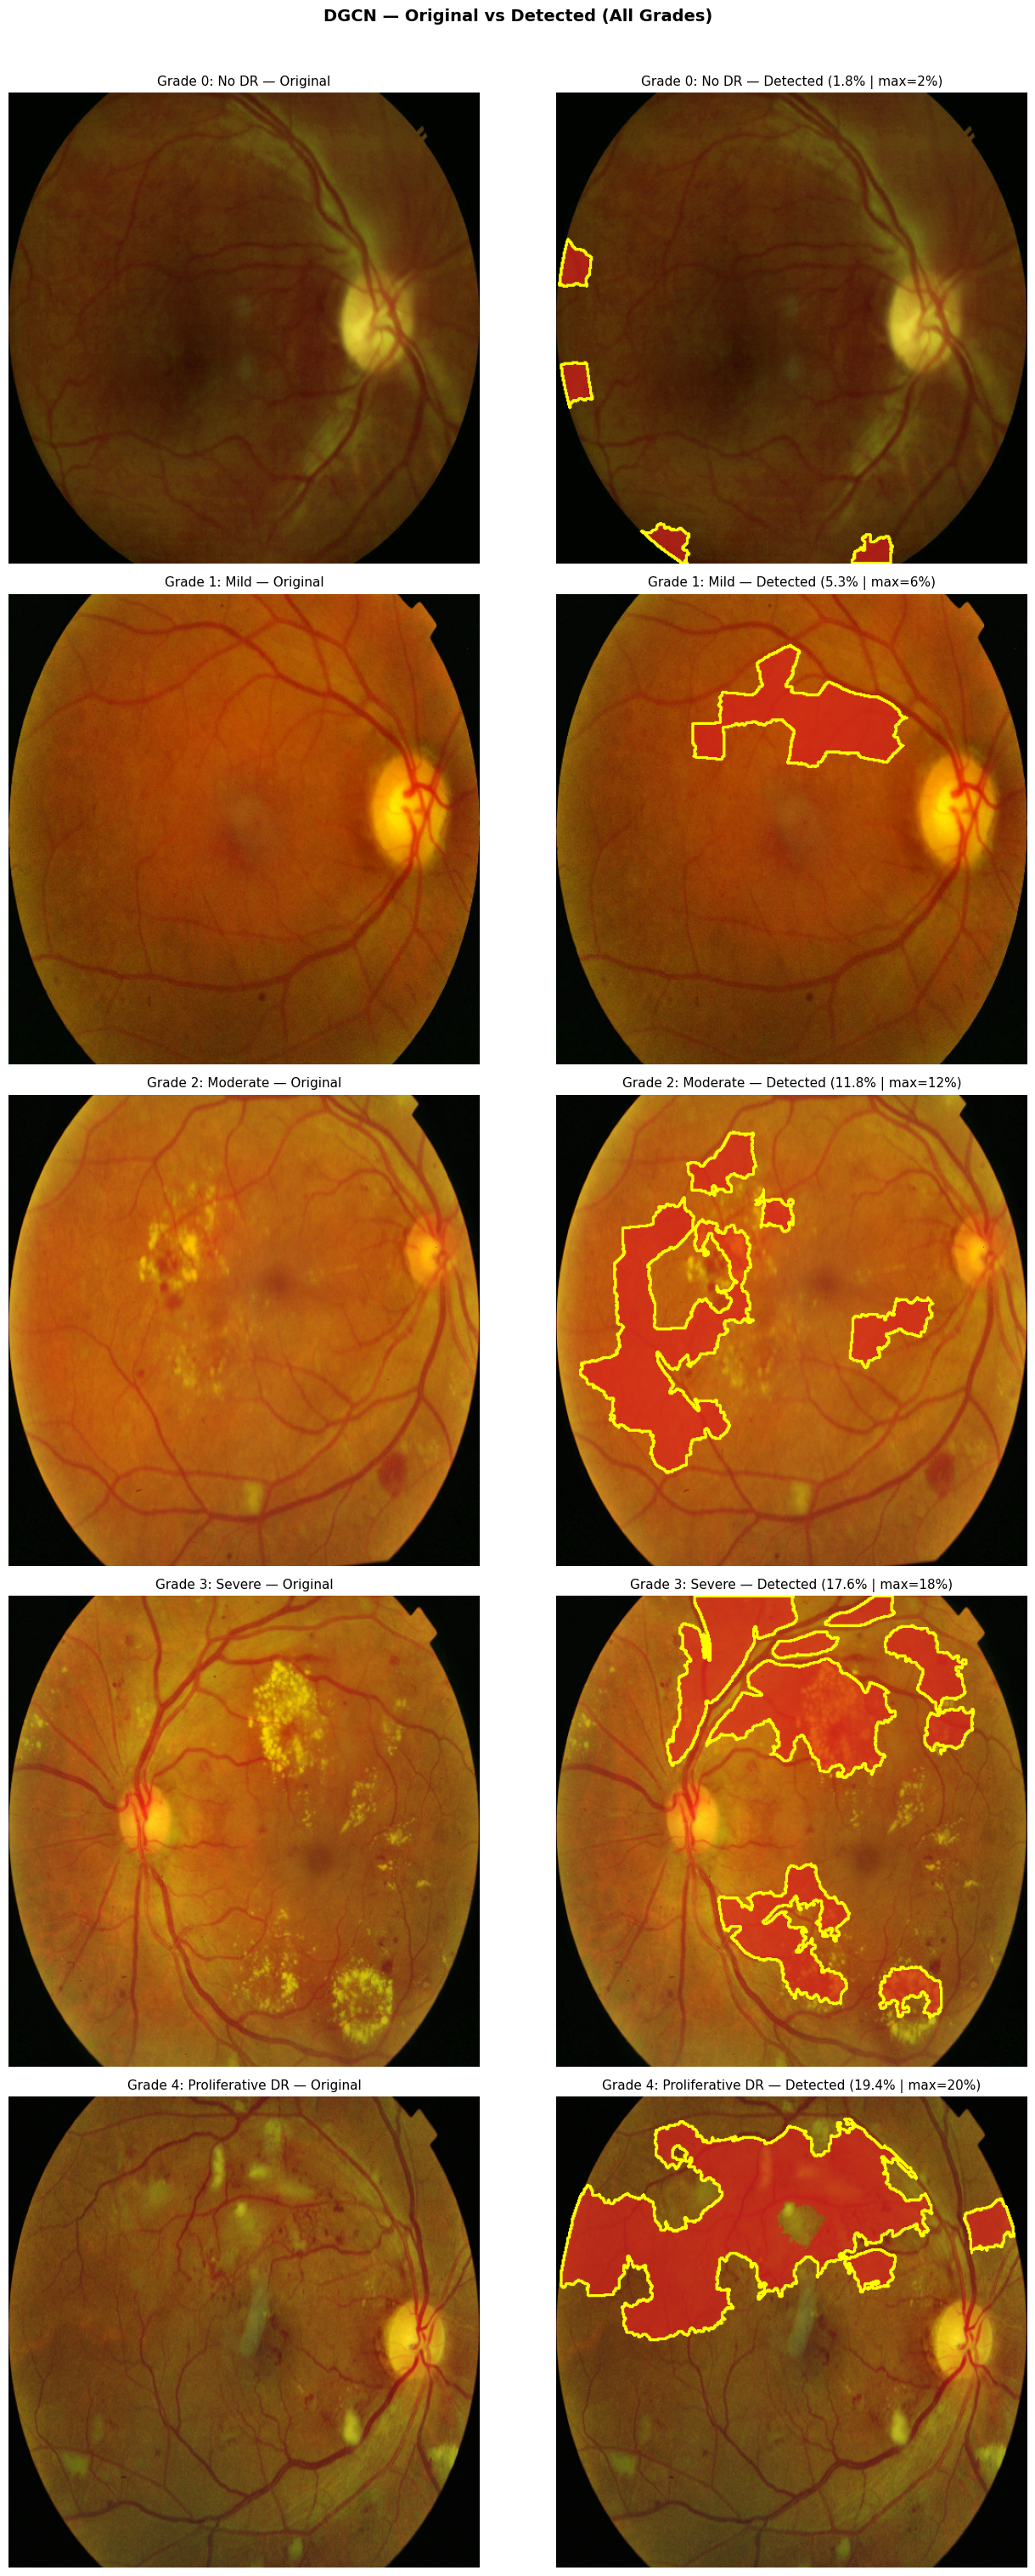

✅ Done


In [ ]:
GRADE_MAX_COVERAGE = {0: 0.02, 1: 0.06, 2: 0.12, 3: 0.18, 4: 0.20}

fig, axes = plt.subplots(5, 2, figsize=(14, 30))

selected = []
for g in [0, 1, 2, 3, 4]:
    subset = df[df["diagnosis"] == g]
    selected.append(subset.iloc[min(3, len(subset)-1)])

for row_idx, row in enumerate(selected):
    img   = preprocess_retinal_image(row["img_path"], size=512)
    grade = int(row["diagnosis"])
    if img is None:
        continue

    dgcn_m = DGCN(embed_dim=256, gcn_hidden=128, gcn_out=64, k=10).to(device)
    opt    = torch.optim.Adam(dgcn_m.parameters(), lr=5e-4)

    Z_r, segs_r, _ = train_dgcn_on_image(
        img, dgcn_m, opt,
        n_segments=200, k=10, lam=2,
        alpha=0.5, beta=0.3, epochs=50
    )

    lmask, _, _ = detect_lesions(
        Z_r, segs_r, img,
        n_clusters=3,
        top_fraction=0.25,
        score_weight=0.65,
        max_coverage=GRADE_MAX_COVERAGE[grade]   # ← grade-specific cap
    )

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(
        f"Grade {grade}: {row['grade_name']} — Original", fontsize=11)
    axes[row_idx, 0].axis("off")

    overlay      = img.copy().astype(np.float32)
    overlay[lmask] = overlay[lmask] * 0.35 + np.array([220, 30, 30]) * 0.65
    lesion_uint8 = lmask.astype(np.uint8) * 255
    contours, _  = cv2.findContours(lesion_uint8, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    overlay_bgr  = cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.drawContours(overlay_bgr, contours, -1, (0, 255, 255), 2)
    overlay_rgb  = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    axes[row_idx, 1].imshow(overlay_rgb)
    axes[row_idx, 1].set_title(
        f"Grade {grade}: {row['grade_name']} — "
        f"Detected ({100*lmask.mean():.1f}% | "
        f"max={100*GRADE_MAX_COVERAGE[grade]:.0f}%)", fontsize=11)
    axes[row_idx, 1].axis("off")

plt.suptitle("DGCN — Original vs Detected (All Grades)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("✅ Done")

In [ ]:
from sklearn.manifold import TSNE

# Use the last trained Z and labels from Cell 19
print("Running t-SNE on GCN features...")

tsne  = TSNE(n_components=2, random_state=42, perplexity=min(30, len(Z)-1))
Z_2d  = tsne.fit_transform(Z)

plt.figure(figsize=(7, 6))
colors = ['#1f77b4', '#d62728']   # blue=background, red=lesion
for c, label in enumerate(['Background', 'Lesion']):
    mask = (sp_labels == (1 - lesion_cluster if c == 1 else lesion_cluster)) \
           if c == 0 else (sp_labels == lesion_cluster)
    # simpler:
    mask = (sp_labels == (lesion_cluster if c == 1 else 1 - lesion_cluster))
    plt.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                c=colors[c], label=label, alpha=0.6, s=20)

plt.legend(fontsize=12)
plt.title("t-SNE of GCN Superpixel Features\n(replicating Paper Fig 3)", fontsize=13)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()
print("✅ t-SNE plot done")